### 1.1.7

In the $xy$ plane mark all nine of these linear combinations:
$$
c\begin{bmatrix} 2 \\ 1 \end{bmatrix} + d\begin{bmatrix} 0 \\ 1 \end{bmatrix}
\quad\text{with}\quad
c=0,\,1,\,2
\quad\text{and}\quad
d=0\,,1,\,2
$$

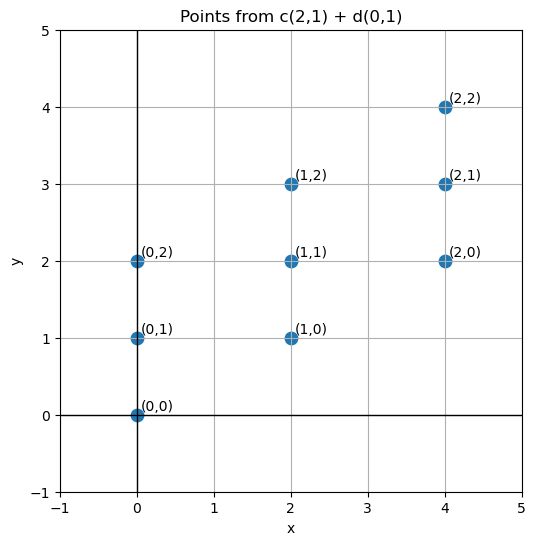

In [4]:
import matplotlib.pyplot as plt

points = []
for c in [0, 1, 2]:
    for d in [0, 1, 2]:
        x = c*2 + d*0
        y = c*1 + d*1
        points.append((x, y, c, d))

xs = [p[0] for p in points]
ys = [p[1] for p in points]

plt.figure(figsize=(6, 6))
plt.scatter(xs, ys, s=80)

for x, y, c, d in points:
    plt.text(x + 0.05, y + 0.05, f"({c},{d})", fontsize=10)

plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.grid(True)
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.xticks(range(-1, 6))
plt.yticks(range(-1, 6))
plt.xlabel("x")
plt.ylabel("y")
plt.title("Points from c(2,1) + d(0,1)")
plt.gca().set_aspect("equal")

plt.show()

### 1.1.9

If three corners of a parallelogram are $(1,1)$, $(4, 2)$, and $(1, 3)$, what are all three of the possible fourth corners? Draw two of them.

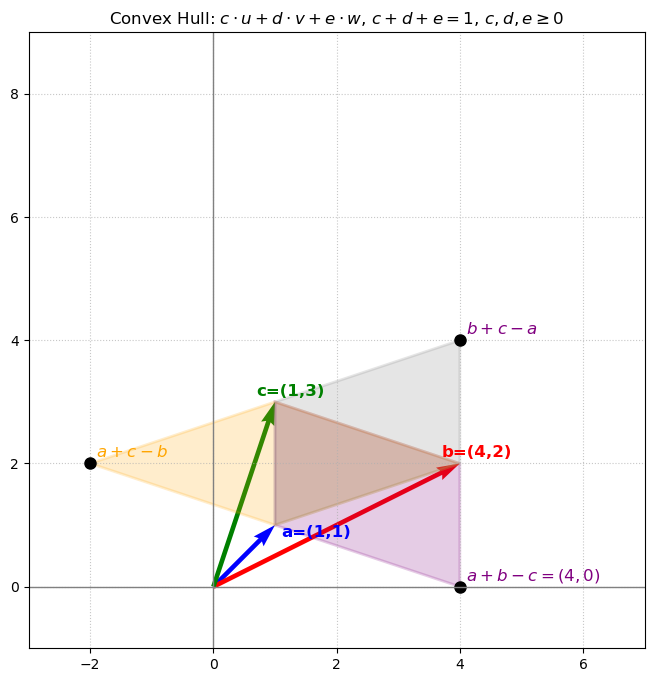

In [106]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

a = {"vec": np.array([1, 1]), "label": "a=(1,1)", "color": "blue",  "offset": ( 0.1, -0.2)}
b = {"vec": np.array([4, 2]), "label": "b=(4,2)", "color": "red",   "offset": (-0.3,  0.1)}
c = {"vec": np.array([1, 3]), "label": "c=(1,3)", "color": "green", "offset": (-0.3,  0.1)}

fig, ax = plt.subplots(figsize=(8, 8))

# Draw the vectors
for item in [a, b, c]:
    vec = item["vec"]
    ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, color=item["color"])
    ax.text(vec[0] + item["offset"][0], vec[1] + item["offset"][1], item["label"], color=item["color"], fontsize=12, fontweight='bold')

# Draw solutions (for clear I draw with points instead of vectors)
sols = [
    {"pt": a["vec"]+b["vec"]-c["vec"], "label": r"$a+b-c=(4,0)$", "color": "purple"}, # ab as diagonal
    {"pt": a["vec"]+c["vec"]-b["vec"], "label": r"$a+c-b$", "color": "orange"}, # ac as diagonal
    {"pt": b["vec"]+c["vec"]-a["vec"], "label": r"$b+c-a$", "color": "purple"}, # bc as diagonal
]

for item in sols:
    pt = item["pt"]
    ax.plot(pt[0], pt[1], 'ko', markersize=8)
    ax.text(pt[0] + 0.1, pt[1] + 0.1, item["label"], color=item["color"], fontsize=12, fontweight="bold")


poly1 = Polygon(np.array([a["vec"], sols[0]["pt"], b["vec"], c["vec"]]), closed=True, alpha=0.2, facecolor='purple', edgecolor='purple', linewidth=2)
ax.add_patch(poly1)

poly2 = Polygon(np.array([a["vec"], b["vec"], c["vec"], sols[1]["pt"]]), closed=True, alpha=0.2, facecolor='orange', edgecolor='orange', linewidth=2)
ax.add_patch(poly2)

poly3 = Polygon(np.array([a["vec"], b["vec"], sols[2]["pt"], c["vec"]]), closed=True, alpha=0.2, facecolor='gray', edgecolor='gray', linewidth=2)
ax.add_patch(poly3)

# Graph styling
ax.set_xlim(-3, 7)
ax.set_ylim(-1, 9)
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)
ax.grid(True, linestyle=':', alpha=0.7)
ax.set_title(r"Convex Hull: $c\cdot u + d\cdot v + e\cdot w,\, c+d+e=1,\, c,d,e\geq 0$")
ax.set_aspect('equal')

plt.show()

### 1.1.16

Mark the point $-v+2w$ and any other combination $c\bm{v}+d\bm{w}$ with $c+d=1$. Draw the line of all combinations that have $c+d=1$.

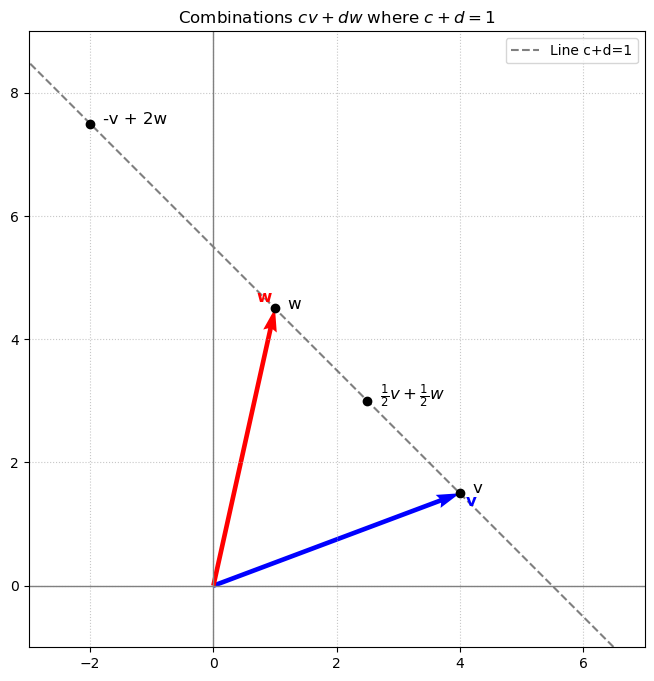

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Define approximate coordinates for vectors v and w based on the image
v = np.array([4, 1.5])
w = np.array([1, 4.5])

fig, ax = plt.subplots(figsize=(8, 8))

# Draw vectors v and w from the origin
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='blue')
ax.text(v[0] + 0.1, v[1] - 0.2, "v", color='blue', fontsize=12, fontweight='bold')

ax.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='red')
ax.text(w[0] - 0.3, w[1] + 0.1, "w", color='red', fontsize=12, fontweight='bold')

# Calculate points for the line c + d = 1
# Using the parametric form: c*v + (1-c)*w
c_vals = np.linspace(-1.5, 2.5, 100)
line_x = [c*v[0] + (1-c)*w[0] for c in c_vals]
line_y = [c*v[1] + (1-c)*w[1] for c in c_vals]

# Plot the infinite dashed line
ax.plot(line_x, line_y, 'k--', alpha=0.5, label='Line c+d=1')

# Define specific points in questions 15 and 16
points_to_mark = [
    (1, 0, "v"),
    (0, 1, "w"),
    (0.5, 0.5, r"$\frac{1}{2}v + \frac{1}{2}w$"),
    (-1, 2, "-v + 2w")
]

# Plot and label the specific combinations
for c, d, label in points_to_mark:
    # Calculate coordinate: c*v + d*w
    pt = c*v + d*w
    ax.plot(pt[0], pt[1], 'ko') # black dot
    ax.text(pt[0] + 0.2, pt[1], label, fontsize=12)

# Graph styling
ax.set_xlim(-3, 7)
ax.set_ylim(-1, 9)
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='upper right')
ax.set_title("Combinations $cv + dw$ where $c + d = 1$")
ax.set_aspect('equal') # Keeps the x and y scale the same so angles are accurate

plt.show()

### 1.1.20

Locate $\frac{1}{3}\mathbf{u}+\frac{1}{3}\mathbf{v}+\frac{1}{3}\mathbf{w}$ and $\frac{1}{2}\mathbf{u}+\frac{1}{2}\mathbf{w}$ in Figure 1.5b. Challenge problem: Under what restrictions on $c,d,e$, will the combinations $c\mathbf{u}+d\mathbf{v}+e\mathbf{w}$ fill in the dashed triangle? To stay in the triangle, one requirement is $c\geq 0, d\geq 0, e\geq 0$.

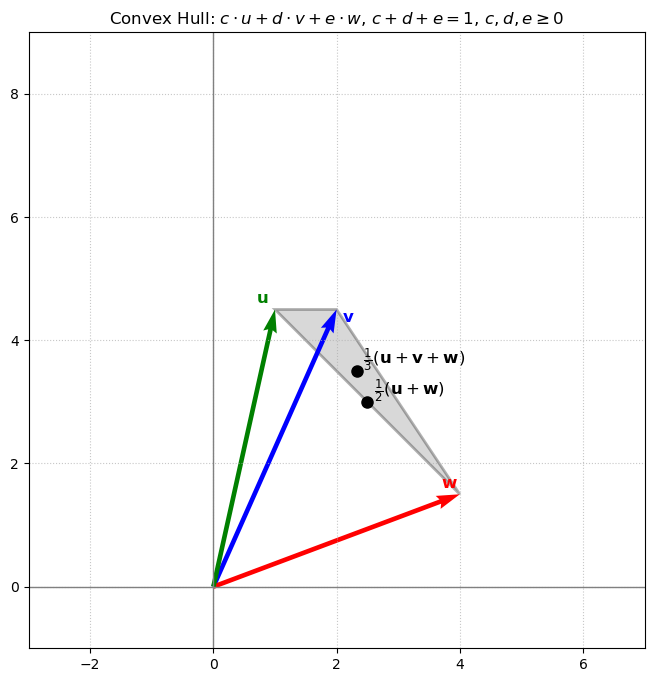

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

vecs = [
    {"vec": np.array([2, 4.5]), "label": "v", "color": "blue",  "offset": ( 0.1, -0.2)},
    {"vec": np.array([4, 1.5]), "label": "w", "color": "red",   "offset": (-0.3,  0.1)},
    {"vec": np.array([1, 4.5]), "label": "u", "color": "green", "offset": (-0.3,  0.1)},
]

# Vertices of the triangle
vertices = np.array([item["vec"] for item in vecs])

fig, ax = plt.subplots(figsize=(8, 8))

# Fill the shaded region (the simplex)
triangle = Polygon(vertices, closed=True, alpha=0.3, facecolor='gray', edgecolor='black', linewidth=2)
ax.add_patch(triangle)

# Draw the vectors
for item in vecs:
    vec = item["vec"]
    ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, color=item["color"])
    ax.text(vec[0] + item["offset"][0], vec[1] + item["offset"][1], item["label"], color=item["color"], fontsize=12, fontweight='bold')

# Draw interesting points
pts = [
    {"pt": 1/3 * sum(item["vec"] for item in vecs), "label": r"$\frac{1}{3}(\mathbf{u}+\mathbf{v}+\mathbf{w})$"},
    {"pt": 0.5 * sum(item["vec"] for item in vecs if item["label"] in ["u", "w"]), "label": r"$\frac{1}{2}(\mathbf{u}+\mathbf{w})$"}
]

for item in pts:
    pt = item["pt"]
    ax.plot(pt[0], pt[1], 'ko', markersize=8)
    ax.text(pt[0] + 0.1, pt[1] + 0.1, item["label"], fontsize=12, fontweight='bold')

# Graph styling
ax.set_xlim(-3, 7)
ax.set_ylim(-1, 9)
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)
ax.grid(True, linestyle=':', alpha=0.7)
ax.set_title(r"Convex Hull: $c\cdot u + d\cdot v + e\cdot w,\, c+d+e=1,\, c,d,e\geq 0$")
ax.set_aspect('equal')

plt.show()

In [ ]:
#